# What is Autoencoder Network?

Autoencoder is a algorithm which input datas reconstruct again. We can say to compy from input to output. Autoencoder consists input, output and hidden layer. Number of hidden layer changes according to model. Hidden layers are used to find important feature. Autoencoder is a unsupervised learning model. It doesn't need to anything label. Autoencoder is used to dimention reduction(or feature extraction) and denoising. Autoencoder can be used to combine some algorith as hybrid. In this notebook, I'm going to explain in basic shape. For this, I used a example model. Let's analyze it.

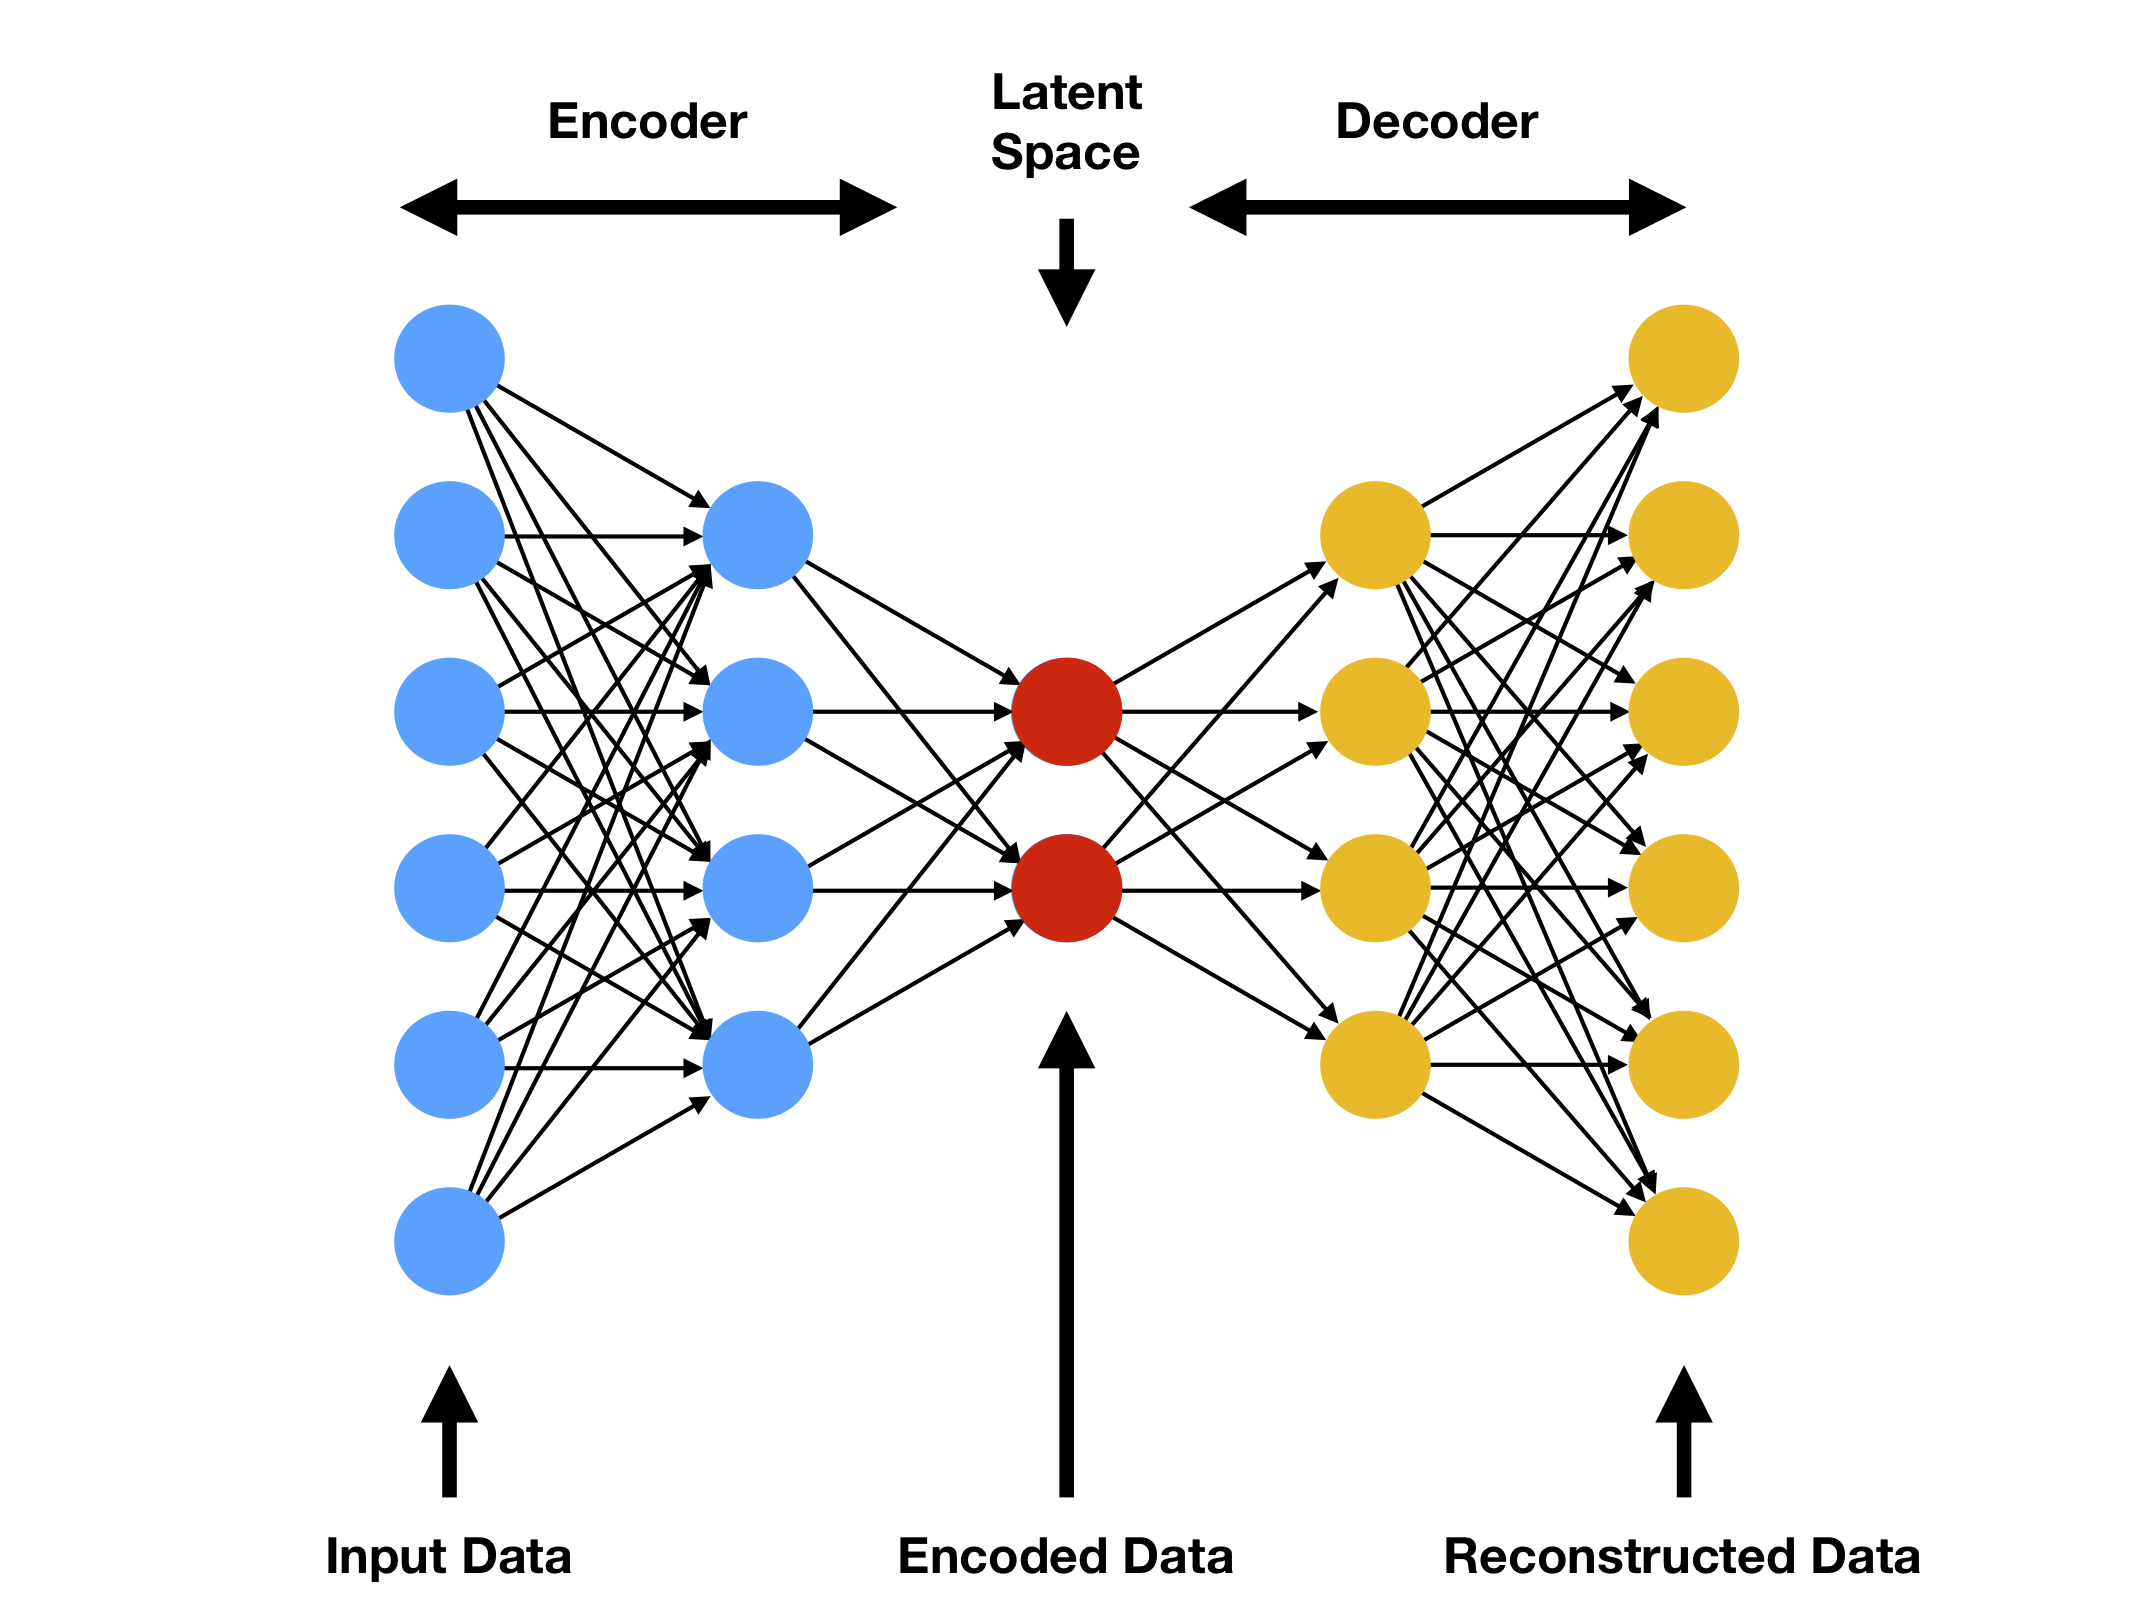

## Libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# data visualization
import matplotlib.pyplot as plt 

# Model Selection
from sklearn.model_selection import train_test_split

# Model Libraries
from keras.models import Model,Sequential
from keras.layers import Input, Dense

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


## Preprocessing

In [2]:
data = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

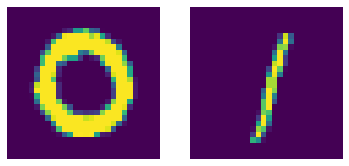

In [3]:
img_size = 28

data_piksel = np.array(data.drop("label",axis=1))

plt.subplot(1,2,1)
plt.imshow(data_piksel[1].reshape(img_size, img_size))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(data_piksel[15].reshape(img_size, img_size))
plt.axis('off')
plt.show()

In [4]:
data_piksel = data_piksel.astype("float32") / 255.0

## Spliting Data

In [5]:
X_train, X_test, _, _ = train_test_split(data_piksel, data.loc[:,"label"], test_size=0.2, random_state=42)

## Creating Model

Number of input neuron and output neuron is equal. Because Autoencoder generates from input to output. Number of hidden layer and neuron is hyper parameter. We can design according to our model. Output activation function is sigmoid if we work to image dataset. 

In [6]:
input_img = Input(shape=(784,))
encoded_1 = Dense(32, activation="relu")(input_img)
encoded_2 = Dense(16, activation="relu")(encoded_1)
decoded_1 = Dense(32, activation="relu")(encoded_2)
output = Dense(784, activation="sigmoid")(decoded_1)

autoencoder = Model(input_img, output)
autoencoder.compile(optimizer="adam",loss="binary_crossentropy")
hist = autoencoder.fit(X_train,X_train,epochs=50,batch_size=128,validation_data=(X_test,X_test))

Epoch 1/50
263/263 [==============================] - 3s 9ms/step - loss: 0.3862 - val_loss: 0.2088
Epoch 2/50
263/263 [==============================] - 2s 8ms/step - loss: 0.1973 - val_loss: 0.1786
Epoch 3/50
263/263 [==============================] - 2s 7ms/step - loss: 0.1744 - val_loss: 0.1650
Epoch 4/50
263/263 [==============================] - 2s 7ms/step - loss: 0.1613 - val_loss: 0.1529
Epoch 5/50
263/263 [==============================] - 2s 7ms/step - loss: 0.1504 - val_loss: 0.1476
Epoch 6/50
263/263 [==============================] - 2s 7ms/step - loss: 0.1458 - val_loss: 0.1449
Epoch 7/50
263/263 [==============================] - 2s 7ms/step - loss: 0.1435 - val_loss: 0.1425
Epoch 8/50
263/263 [==============================] - 2s 7ms/step - loss: 0.1406 - val_loss: 0.1401
Epoch 9/50
263/263 [==============================] - 2s 7ms/step - loss: 0.1387 - val_loss: 0.1386
Epoch 10/50
263/263 [==============================] - 2s 7ms/step - loss: 0.1375 - val_loss: 0.1376

## Model Evaluation

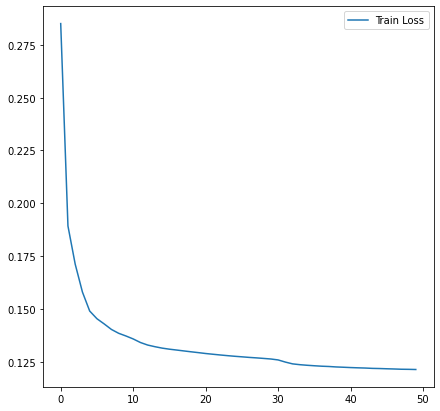

In [7]:
plt.figure(figsize=(7,7))
plt.plot(hist.history["loss"],label="Train Loss")
plt.legend()
plt.show()

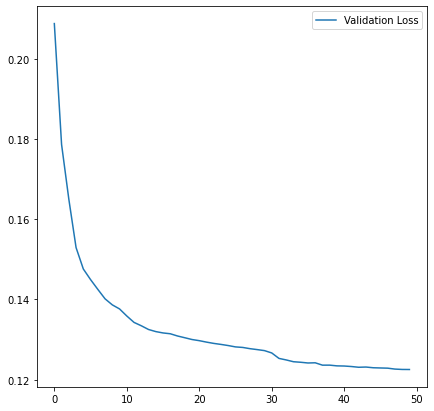

In [8]:
plt.figure(figsize=(7,7))
plt.plot(hist.history["val_loss"],label="Validation Loss")
plt.legend()
plt.show()

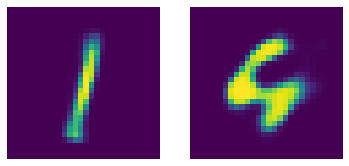

In [9]:
prediction = autoencoder.predict(X_test)

plt.subplot(1,2,1)
plt.imshow(prediction[1].reshape(img_size, img_size))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(prediction[15].reshape(img_size, img_size))
plt.axis('off')
plt.show()

## Conclusion

In this kernal I explained:

* What is the Autoencoder Model
* Where is the Autoencoder Model
* Autoencoder Struct and Working Principle
* I coded a example model.

Thank you so much for analyzing my notebook. If it is benefit for you, please upvote my notebook. You can comment your ideas or questions. I'm looking forward your ideas.

Enjoy with Deep Learning !